**1. Importing required libraries**

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings as wr
wr.filterwarnings('ignore')

**2. Reading Dataset**

In [ ]:
from google.colab import drive
drive.mount('/content/drive')

path = "/content/drive/MyDrive/mart_user_ratings.parquet"
df = pd.read_parquet(path)
print(df.head(5))

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
                            user_id   book_id                   book_title  \
0  733d1a864a29c2a337e4c4862a865dcb  18071590                Me Before You   
1  8331156ffec5f492e4a10a85f4aaac85    298230                   Agnes Grey   
2  73fe252243e1a82acc7b407f12114d91     73070             It Had to Be You   
3  b0579d39685bf9ea52d519ba28b6a1d2   6068551                       Shiver   
4  20bfb3356b796552cdbb9115872e7e50     17125  Odin den' Ivana Denisovicha   

   user_rating                        book_author_names  book_average_rating  \
0            3               [Emo Malmberg, Jojo Moyes]                 4.27   
1            3           [Angeline Goreau, Anne Bronte]                 3.65   
2            0               [Susan Elizabeth Phillips]                 4.04   
3            0                      [Maggie Stiefvater]                 3.78   
4 

**3. Analyzing the Data**

In [ ]:
df.shape

(5000000, 12)

In [ ]:
df.columns

Index(['user_id', 'book_id', 'book_title', 'user_rating', 'book_author_names',
       'book_average_rating', 'book_publication_year', 'book_genre_1',
       'book_genre_2', 'book_genre_3', 'book_genre_4', 'book_genre_5'],
      dtype='object')

In [ ]:
df.dtypes


,0
user_id,object
book_id,int32
book_title,object
user_rating,int32
book_author_names,object
book_average_rating,float32
book_publication_year,float64
book_genre_1,object
book_genre_2,object
book_genre_3,object


**4. Checking missing values**

In [ ]:
# Checking for missing values
missing_values = df.isnull().sum()
print("Missing Values:\n", missing_values)

# Percentage of missing values
missing_percentage = (missing_values / len(df)) * 100
print("\nPercentage of Missing Values:\n", missing_percentage)

Missing Values:
 user_id                        0
book_id                        0
book_title                   376
user_rating                    0
book_author_names              0
book_average_rating          376
book_publication_year     796623
book_genre_1               44258
book_genre_2              326605
book_genre_3              734689
book_genre_4             1180795
book_genre_5             1936030
dtype: int64

Percentage of Missing Values:
 user_id                   0.00000
book_id                   0.00000
book_title                0.00752
user_rating               0.00000
book_author_names         0.00000
book_average_rating       0.00752
book_publication_year    15.93246
book_genre_1              0.88516
book_genre_2              6.53210
book_genre_3             14.69378
book_genre_4             23.61590
book_genre_5             38.72060
dtype: float64


**5. Handling missing values**

In [ ]:
df = df.dropna(subset = ['book_title', 'book_average_rating'])
df['book_publication_year'] = pd.to_numeric(
    df['book_publication_year'],
    errors='coerce'
)

In [ ]:
genre_cols = [
    'book_genre_1',
    'book_genre_2',
    'book_genre_3',
    'book_genre_4',
    'book_genre_5'
]

df[genre_cols] = df[genre_cols].fillna('No genre')

**6. Checking outliers**

In [ ]:
Q1 = df['book_average_rating'].quantile(0.25)
Q3 = df['book_average_rating'].quantile(0.75)

IQR = Q3 - Q1

lower = Q1 - 1.5 * IQR
upper = Q3 + 1.5 * IQR

outliers = df[
    (df['book_average_rating'] < lower) |
    (df['book_average_rating'] > upper)
]

print("Number of outliers:", len(outliers))
print("Lower bound:", lower)
print("Upper bound:", upper)

Number of outliers: 93385
Lower bound: 3.2150001525878906
Upper bound: 4.694999694824219


**7. Descriptive Analysis**

- User rating distribution

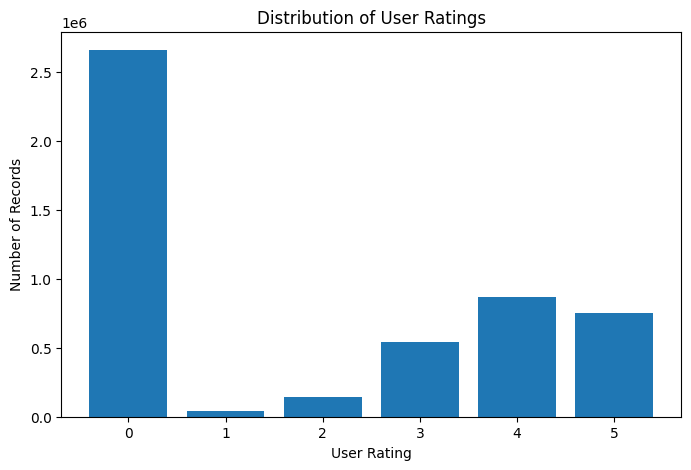

In [ ]:
rating_counts = df['user_rating'].value_counts().sort_index()

plt.figure(figsize=(8, 5))

plt.bar(rating_counts.index.astype(str), rating_counts.values)

plt.xlabel('User Rating')
plt.ylabel('Number of Records')
plt.title('Distribution of User Ratings')

plt.show()

More than half of the records (~2.7 million) have a user rating of 0, suggesting a substantial amount of unrecorded rating data, which means most users do not leave a rating for books.

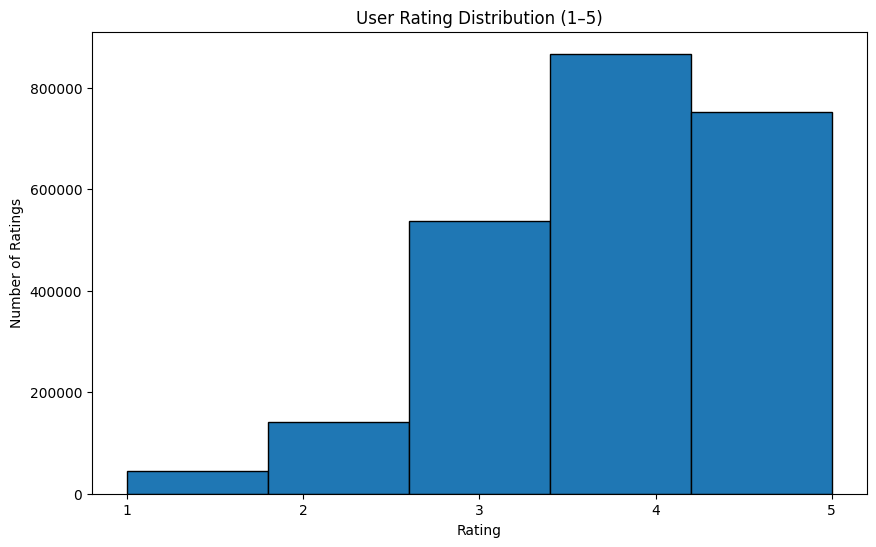

In [ ]:
# Plot real user rating
df_rated = df[df['user_rating'] > 0]

plt.figure(figsize=(10, 6))

plt.hist(
    df_rated['user_rating'],
    bins=5,
    edgecolor='black'
)

plt.xlabel('Rating')
plt.ylabel('Number of Ratings')
plt.title('User Rating Distribution (1–5)')
plt.xticks(range(1, 6))

plt.show()

The majority of ratings are 4 and 5, while ratings 1 and 2 are much less frequent.

Rating 4 is the most common.

Since most observations are concentrated towards 4-5, the distribution is left-skewed.

- Distribution of user ratings across genre

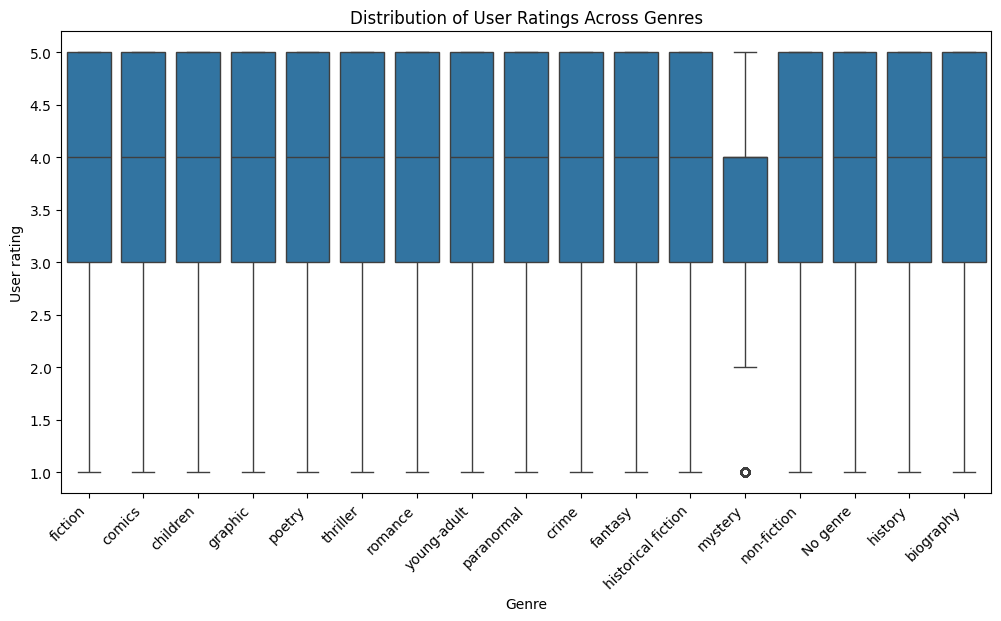

In [ ]:
# Keep valid ratings only
plt.figure(figsize=(12, 6))

sns.boxplot(
    data=df_rated,
    x='book_genre_1',
    y='user_rating'
)

plt.xticks(rotation=45, ha='right')
plt.xlabel('Genre')
plt.ylabel('User rating')
plt.title('Distribution of User Ratings Across Genres')
plt.show()

Poetry's books has the highest average rating, approximately more than 4, while Biography has the lowest rating among the top 10.

- Book Popularity vs Average Rating

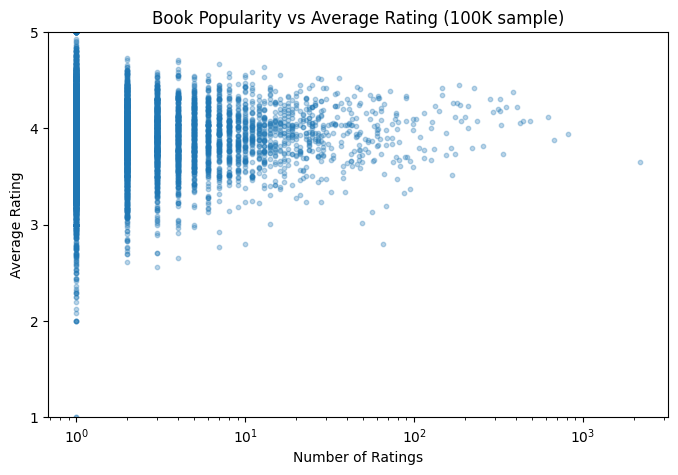

In [ ]:
book_stats = df_rated.groupby('book_id').agg(
    rating_count=('user_rating', 'count'),
    average_rating=('book_average_rating', 'first')
).reset_index()

plot_sample = book_stats.sample(
    n=min(10000, len(book_stats)),
    random_state=42
)

plt.figure(figsize=(8,5))

plt.scatter(
    plot_sample['rating_count'],
    plot_sample['average_rating'],
    alpha=0.3,
    s=10
)

plt.xscale('log')
plt.xlabel('Number of Ratings')
plt.ylabel('Average Rating')
plt.title('Book Popularity vs Average Rating (100K sample)')

plt.ylim(1, 5)
plt.yticks(range(1, 6))

plt.show()

Books with few ratings (1 to 10 ratings on the log scale) show extreme rating variance, spanning all the way from 1.0 to 5.0 stars.

As the number of ratings grows past 100 towards 1000, the variance narrows sharply.

Highly popular books maintain strong average scores (approx. 3.5 - 4.5), with very few popular books falling below 3.0.

- User Activity vs Average Rating

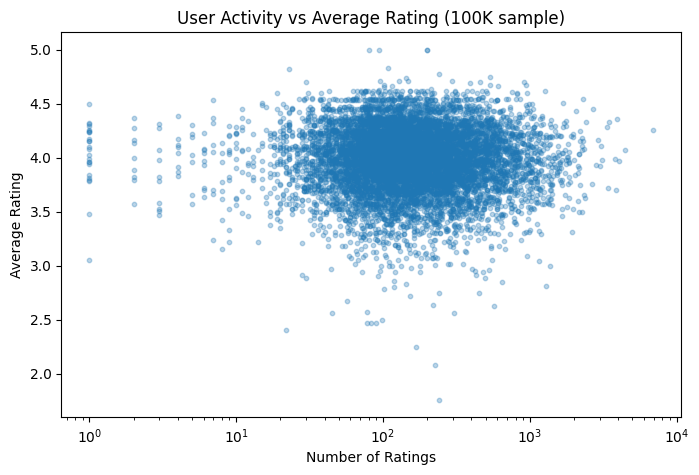

In [ ]:
user_stats = df_rated.groupby('user_id').agg(
    rating_count=('user_rating', 'count'),
    average_rating=('book_average_rating', 'first')
)

plot_sample_2 = user_stats.sample(
    n=min(100000, len(user_stats)),
    random_state=42
)

plt.figure(figsize=(8,5))

plt.scatter(
    user_stats['rating_count'],
    user_stats['average_rating'],
    alpha=0.3,
    s=10
)

plt.xscale('log')
plt.xlabel('Number of Ratings')
plt.ylabel('Average Rating')
plt.title('User Activity vs Average Rating (100K sample)')

plt.show()

Unlike the book popularity plot, the user density is heavily concentrated in the mid-to-high activity region (10 to 1000 ratings per user), peaking around 100 ratings.

The mean rating remains consistently centered around 4.0 stars.

Power (highly-active) users (those with 100 to 1000 ratings) show very few mean scores below 3.0 stars.

Active reviewers do not become overly hyper-critical on average; instead, they consistently rate items positively over time.

- Correlation Matrix

In [ ]:
numeric_cols = df.select_dtypes(include='number').columns

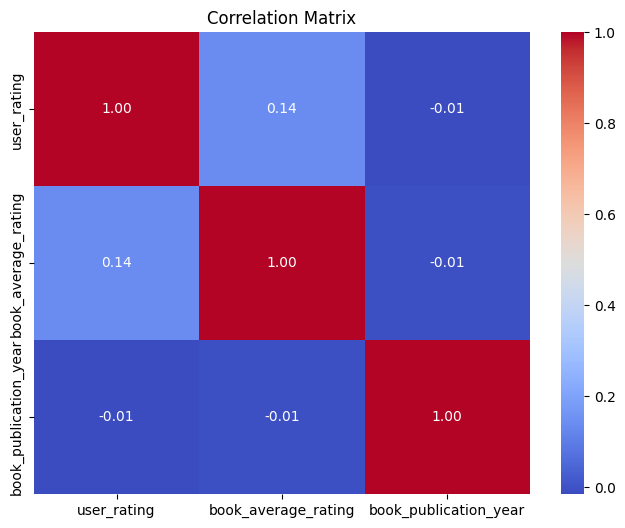

In [ ]:
df[
    ['user_rating',
     'book_average_rating',
     'book_publication_year']
].corr()

numeric_cols = [
    'user_rating',
    'book_average_rating',
    'book_publication_year'
]

corr = df[numeric_cols].corr()

plt.figure(figsize=(8,6))

sns.heatmap(
    corr,
    annot=True,
    cmap='coolwarm',
    fmt='.2f'
)

plt.title('Correlation Matrix')

plt.show()

The correlation matrix highlights key relationships among individual user ratings, overall book average ratings, and publication years:
- Weak-to-Moderate Positive Relationship Between Individual Ratings and Book Average Rating (r = 0.14): A user's rating has a modest positive correlation with a book's overall average rating.

-> Knowing a book's overall average rating gives you almost no ability to predict how an individual user will rate it. Personal preference and variance dominate over consensus quality

- No Relationship with Publication Year (r = 0.01 and r = 0.02):
Publication year (book_publication_year) shows virtually zero linear correlation with both individual user ratings and overall book average ratings.

-> A book's age or recency has no impact on its quality score or user appreciation—older classics and newly published books perform identically on average